In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
H22 = pd.read_csv('../data/Howell_2022.txt')
H22 = H22[(H22['QF'] == 'D')&(H22['ID'].str.contains('RGB'))]
Y25 = pd.read_csv('M4_seismicanalysis_Yingxiang_Feb25.csv')
Y25 = Y25[(Y25['Quality_flag'] == 'D')&(Y25['evol_stage'] == 'RGB')&(Y25['numax_pyMon']>12)&(Y25['Delta_nu']>0)]
Y25

,star_id,evol_stage,Gaia_source_ID_DR3,2MASS_ID,Gmag,Quality_flag,numax_pyMon,numax_err_pyMon,Teff_final,Teff_err_final,Lum_bol,Lum_bol_err_random,Lum_bol_err_systematic,Mass,Mass_err_rand,Delta_nu,delta_nu_02,epsilon
3,M4RGB165,RGB,6.050000e+18,16230993-2628335,13.98,D,91.848136,2.085416,5287,108.001212,22.97,0.44,2.69,0.93,0.07,8.35,NaN,0.920
13,M4RGB188,RGB,6.050000e+18,16232169-2626468,13.04,D,30.981079,0.568750,4810,108.001212,44.00,1.53,5.11,0.84,0.07,3.75,NaN,0.600
15,M4RGB104,RGB,6.050000e+18,16232195-2630320,13.13,D,33.730326,0.568750,4851,108.001212,38.85,1.28,4.51,0.78,0.06,4.32,0.130,0.926
16,M4RGB17,RGB,6.050000e+18,16232252-2629422,13.54,D,51.888145,0.710937,4785,61.000000,28.35,0.60,3.29,0.92,0.05,5.84,0.170,1.230
22,M4RGB13,RGB,6.050000e+18,16232508-2629530,13.52,D,49.202833,1.990624,4840,108.001212,26.95,0.90,3.12,0.79,0.07,6.39,0.120,1.290
27,M4RGB229,RGB,6.050000e+18,16232982-2623253,12.49,D,15.949854,0.178361,4677,54.000000,73.89,1.62,8.58,0.80,0.04,2.66,0.190,0.920
32,M4RGB23,RGB,6.050000e+18,16233236-2629222,13.36,D,42.553491,1.042708,4897,108.001212,31.25,0.97,3.62,0.77,0.06,5.39,0.130,1.080
35,M4RGB37,RGB,6.050000e+18,16233380-2627497,13.14,D,35.136918,0.663541,4821,108.001212,39.61,1.35,4.60,0.85,0.07,4.86,0.170,0.890
36,M4RGB129,RGB,6.050000e+18,16233414-2630104,13.76,D,70.173835,1.990624,4989,108.001212,22.63,0.62,2.63,0.86,0.07,7.35,0.130,1.240
44,M4RGB252,RGB,6.050000e+18,16233768-2620381,13.57,D,55.276752,0.663541,5012,60.000000,26.65,0.41,3.09,0.78,0.04,5.84,0.130,1.050


In [5]:
numax = H22['νmax'].str.split('±', expand=True)[0].astype(float)
enumax = H22['νmax'].str.split('±', expand=True)[1].astype(float)

dnu = H22['∆ν'].str.split('±', expand=True)[0].astype(float)
ednu = H22['∆ν'].str.split('±', expand=True)[1].astype(float)

LPhot = H22['L/L⊙'].str.split('±', expand=True)[0].astype(float)
eLPhot = 0.5*np.sqrt(H22['L/L⊙'].str.split('±', expand=True)[1].astype(float)**2 + H22['L/L⊙'].str.split('±', expand=True)[2].astype(float)**2)


Teff = H22['Teff'].str.split('±', expand=True)[0].astype(float)
eTeff = H22['Teff'].str.split('±', expand=True)[1].astype(float)

mask = numax > 15

obs = {'FeH':-1.1*np.ones_like(Teff.values),  'Teff':Teff.values, 'numax':numax.values, 'dnuSer':dnu.values,'logLPhot':np.log10(LPhot.values)}
unc = {'Teff':eTeff.values, 'numax': enumax.values, 'dnuSer':ednu.values, 'FeH':0.07*np.ones_like(Teff.values), 'logLPhot':eLPhot.values/LPhot.values*1/np.log(10), 'LPhot':eLPhot.values}

for key in list(obs.keys()):
    obs[key] = obs[key][mask]
    unc[key] = unc[key][mask]

Text(0, 0.5, 'Count')

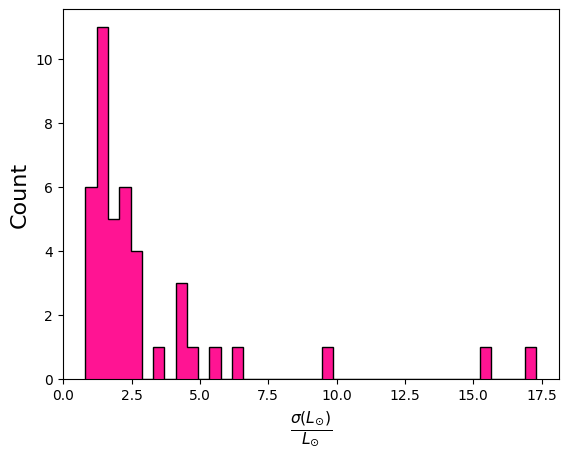

In [6]:
plt.hist(unc['LPhot'], histtype = 'step', fill = True, color = 'deeppink', edgecolor = 'black', bins = 40)
plt.xlabel(r'$\frac{\sigma(L_{\odot})}{L_{\odot}}$', fontsize = 16)
plt.ylabel('Count', fontsize = 16)
#plt.savefig('../figs/H22-LPhot-frac-error.png', bbox_inches = 'tight')

In [10]:
np.min(unc['dnuSer'])

np.float64(0.03)

Text(0, 0.5, 'Count')

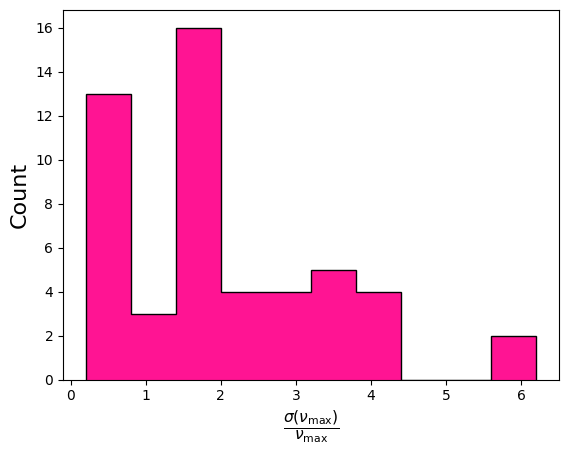

In [18]:
plt.hist(enumax, histtype = 'step', fill = True, color = 'deeppink', edgecolor = 'black')
plt.xlabel(r'$\frac{\sigma(\nu_{\mathrm{max}})}{\nu_{\mathrm{max}}}$', fontsize = 16)
plt.ylabel('Count', fontsize = 16)
#plt.savefig('../figs/H22-numax-frac-error.png', bbox_inches = 'tight')

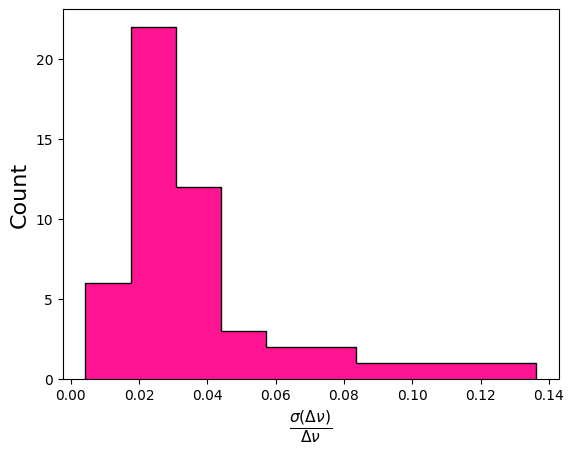

In [19]:
plt.hist(ednu/dnu, histtype = 'step', fill = True, color = 'deeppink', edgecolor = 'black')
plt.xlabel(r'$\frac{\sigma(\Delta \nu)}{\Delta \nu}$', fontsize = 16)
plt.ylabel('Count', fontsize = 16)
plt.savefig('../figs/H22-dnu-frac-error.png', bbox_inches = 'tight')